## Number of Islands II

You are given an empty 2D binary grid of size **m x n.** The grid represents a map where **0** represents water and **1** represents land.

Initially, all the cells of the grid are water.

You are given a list of positions positions, where positions[i] = [ri, ci] is the position at which land is added to the grid.

Return an array of integers answer where answer[i] is the number of islands after turning the cell (ri, ci) into land.

An island is surrounded by water and is formed by connecting adjacent lands horizontally or vertically. You may assume all four edges of the grid are surrounded by water.

Example 1:
Input: m = 3, n = 3, positions = [[0,0],[0,1],[1,2],[2,1]]
Output: [1,1,2,3]
Example 2:
Input: m = 1, n = 1, positions = [[0,0]]
Output: [1]

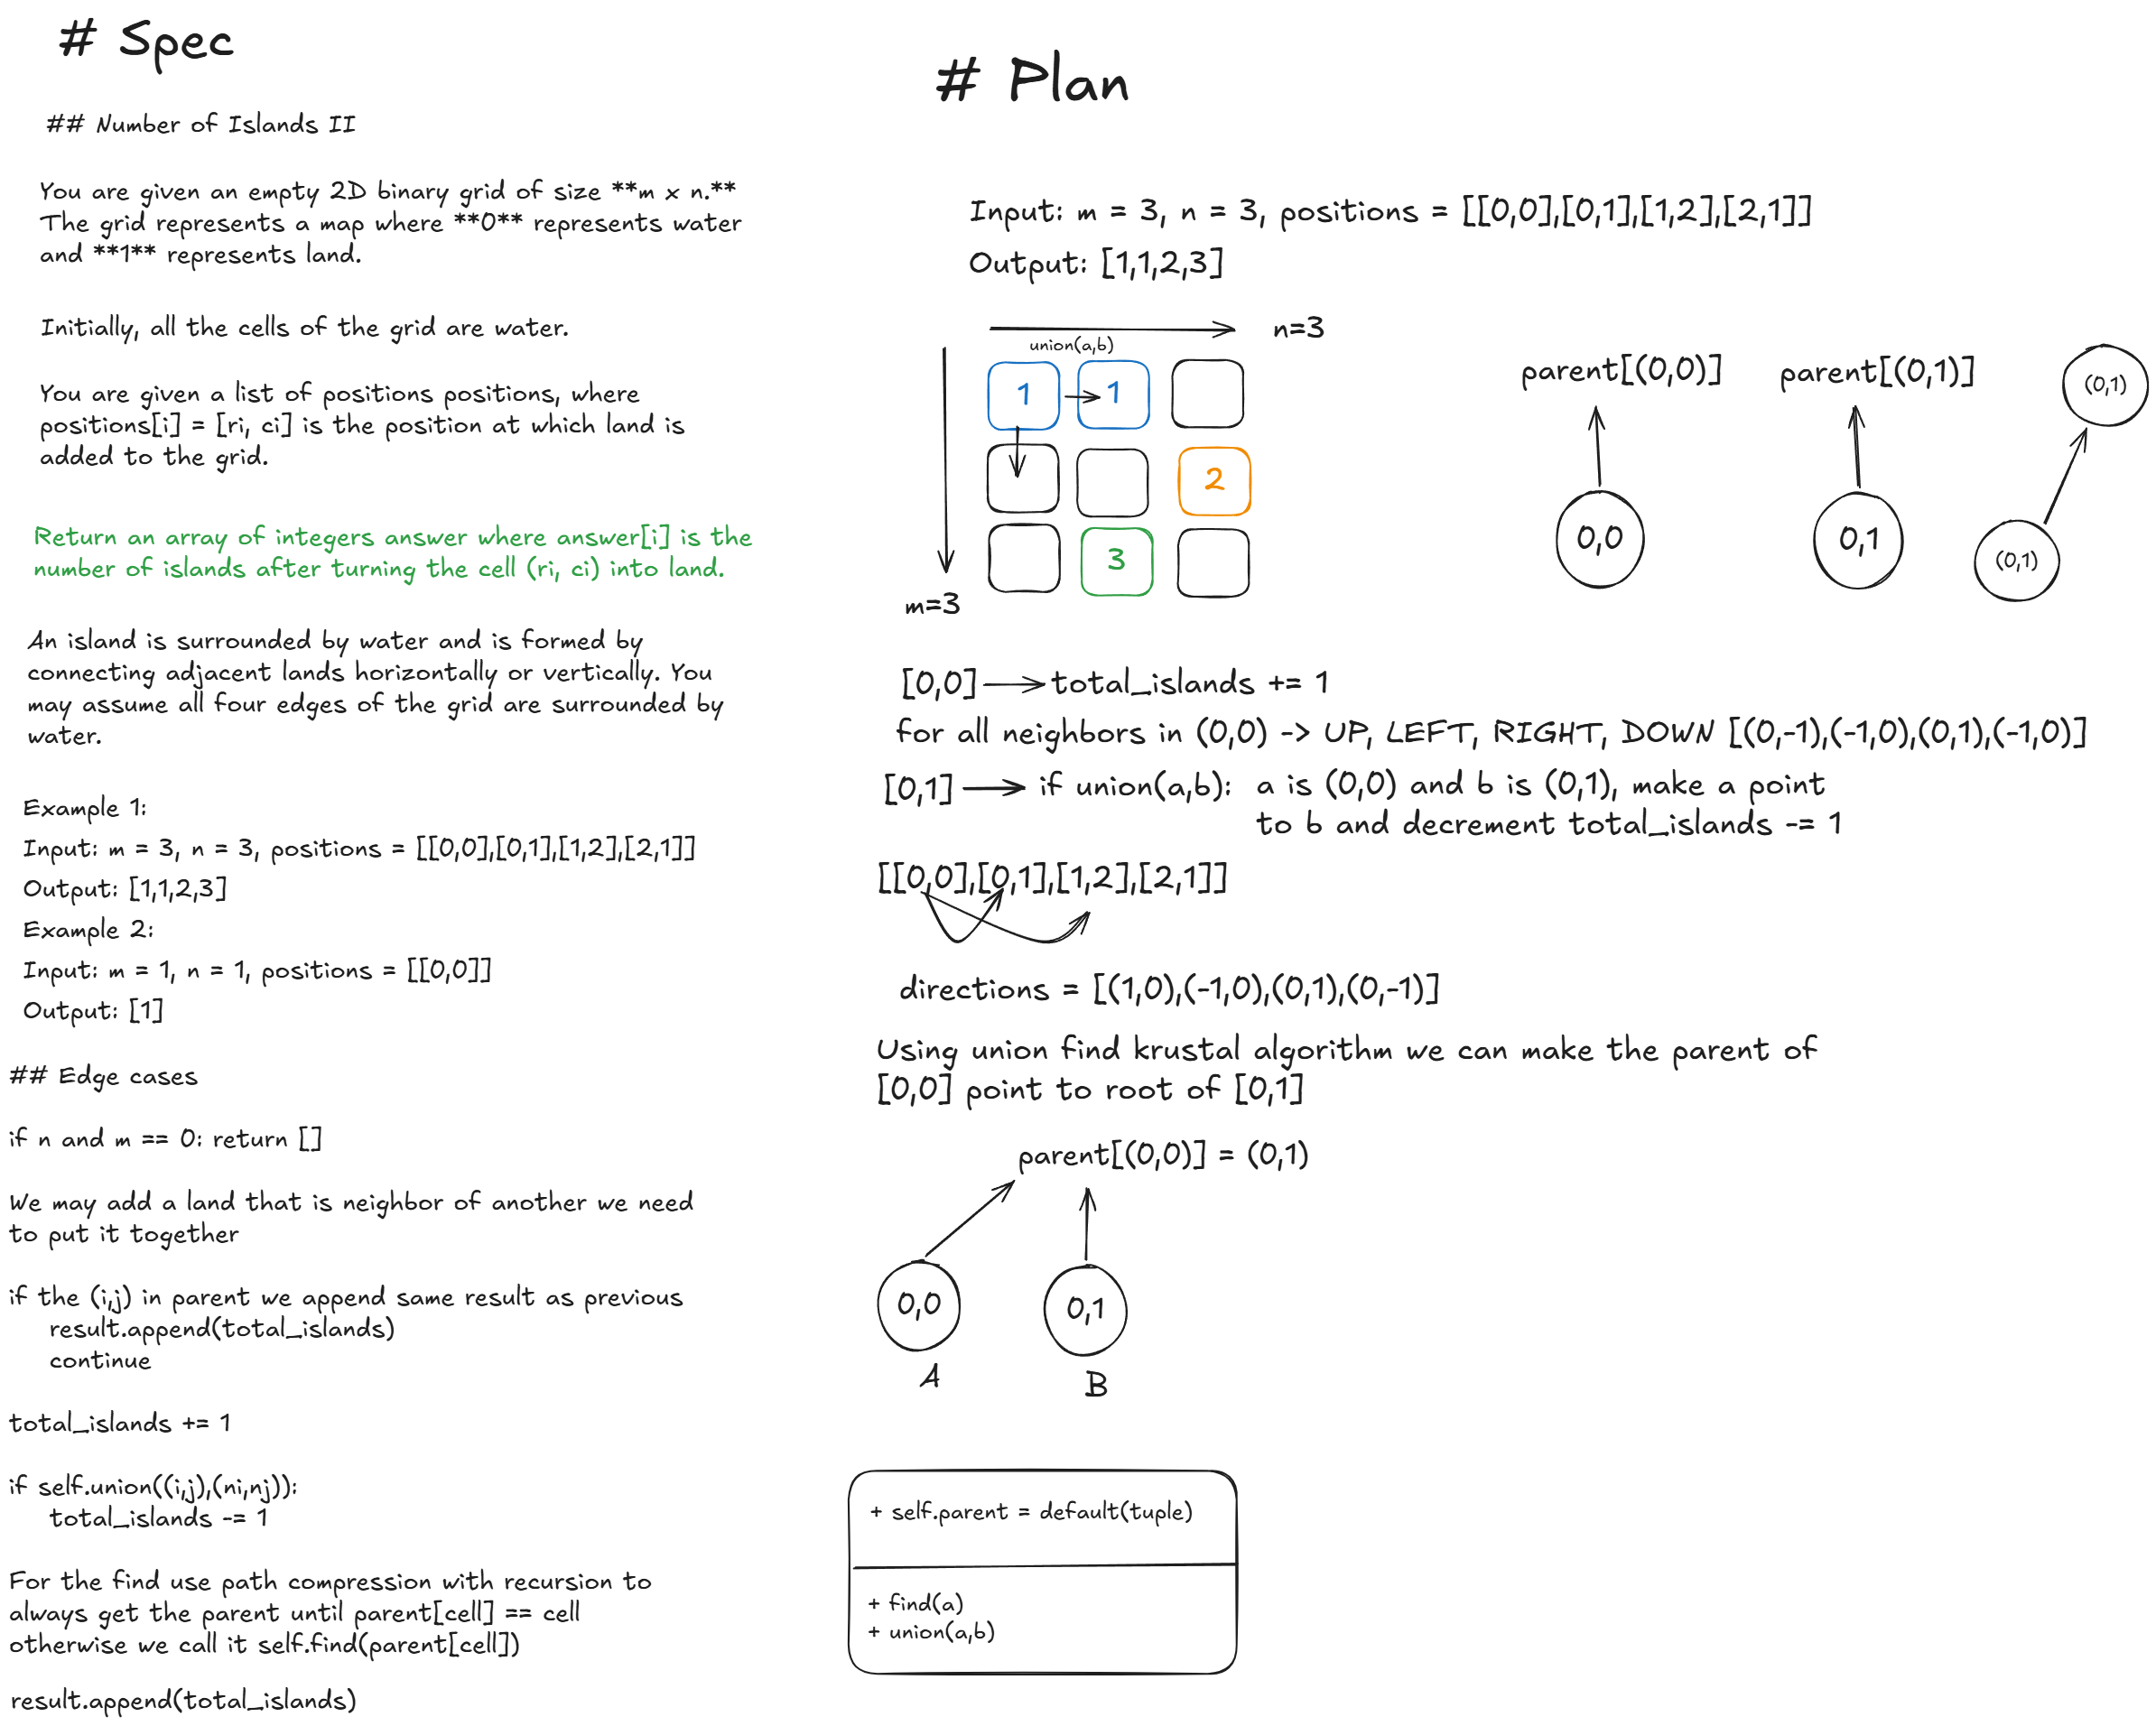

In [ ]:
from typing import List, Tuple, Dict

class Solution:
    def num_of_islands2(self, m: int, n: int, positions: List[List[int]]) -> List[int]:
        # parent: para cada célula de terra, guarda quem é o "chefe" (raiz) da ilha
        parent: Dict[Tuple[int, int], Tuple[int, int]] = {}
        count = 0  # número atual de ilhas
        result = []  # resposta incremental

       
        def find_root(cell: Tuple[int, int]) -> Tuple[int, int]:
            if parent[cell] != cell:
               parent[cell] = find_root(parent[cell])
            return parent[cell]
       

        def union(a: Tuple[int, int], b: Tuple[int, int]) -> bool:
            """
            Une os conjuntos (ilhas) de a e b, se forem diferentes.
            Retorna True se uniu (ou seja, eram ilhas separadas), False se já estavam juntos.
            """
            root_a, root_b = find_root(a), find_root(b)
            if root_a != root_b:
                parent[root_a] = root_b  # Faz a raiz de a apontar para a raiz de b
                return True
            return False

        for i, j in positions:
            if (i, j) in parent:
                # Se já é terra, só repete o número de ilhas
                result.append(count)
                continue
            parent[(i, j)] = (i, j)
            count += 1  # Nova ilha
            # Tenta unir com vizinhos já existentes
            for di, dj in [(-1,0),(1,0),(0,-1),(0,1)]:
                ni, nj = i + di, j + dj
                if not (0 <= ni < m) or not (0 <= nj < n):
                    continue
                elif (ni, nj) in parent:
                    # Se vizinho já é terra, une as ilhas
                    if union((i, j), (ni, nj)):
                        count -= 1  # Duas ilhas viraram uma só
            result.append(count)  # Salva o número de ilhas após esta adição
        return result

# Exemplo de uso:
m, n = 3, 3
positions = [[0,0],[0,1],[1,2],[2,1]]
sol = Solution()
print(sol.num_of_islands2(m, n, positions))  # Saída esperada: [1, 1, 2, 3]
